# MzansiLM-125M

Model-card: https://huggingface.co/uctnlp/mzansilm-125m

Code: https://github.com/Anri-Lombard/sallm/blob/main/src/main/sallm/fine_tune/run.py

**2026/09/09**

In [1]:
import math
import torch
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer

In [2]:
MODEL_NAME = "uctnlp/mzansilm-125m"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model.eval();

In [3]:
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(65536, 512, padding_idx=2)
    (layers): ModuleList(
      (0-29): 30 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=512, out_features=504, bias=False)
          (k_proj): Linear(in_features=512, out_features=168, bias=False)
          (v_proj): Linear(in_features=512, out_features=168, bias=False)
          (o_proj): Linear(in_features=504, out_features=512, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=512, out_features=1536, bias=False)
          (up_proj): Linear(in_features=512, out_features=1536, bias=False)
          (down_proj): Linear(in_features=1536, out_features=512, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((512,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((512,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((512,), eps=1e-05)
    (r

## Model and Tokenizer configuration

In [4]:
print("Model class:", model.__class__.__name__)
print("Model device:", next(model.parameters()).device)

Model class: LlamaForCausalLM
Model device: cuda:0


**Architecture: decoder-only `LlamaForCausalLM`**

In [5]:
print("Model type:", model.config.model_type)
print("Hidden size:", model.config.hidden_size)
print("Number of layers:", model.config.num_hidden_layers)
print("Attention heads:", model.config.num_attention_heads)

Model type: llama
Hidden size: 512
Number of layers: 30
Attention heads: 9


In [6]:
# Check actual vocabulary size BEFORE LoRA wrapping
actual_vocab = int(model.lm_head.weight.shape[0])

print("Model vocab size:", actual_vocab)
print("Vocabulary size:", model.config.vocab_size)
print("Tokenizer vocab size:", len(tokenizer))

Model vocab size: 65536
Vocabulary size: 65536
Tokenizer vocab size: 65536


In [7]:
if tokenizer.chat_template is None:
    print("Tokenizer chat template not found.")

Tokenizer chat template not found.


In [8]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("tokenizer.pad_token was not set, setting it to eos_token: %s", tokenizer.eos_token)
else:
    print("tokenizer.pad_token was set. no action needed.")

tokenizer.pad_token was set. no action needed.


In [9]:
print("Tokenizer max length:", tokenizer.model_max_length)

Tokenizer max length: 1000000000000000019884624838656


In [10]:
print(model.config.max_position_embeddings)

2048


## Notes
1. 💡 **maximum context length of 2048 tokens**
2. 💡 <mark>This is a base language model, not an instruction-tuned chat model, so outputs are plain text continuations of the prompt.</mark>

## Usage 

In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

In [12]:
inputs = tokenizer("Namuhla sifunda ngolimi ngoba abantu", return_tensors="pt")
outputs = model.generate(
    **inputs,
    max_new_tokens=50,
    pad_token_id=tokenizer.pad_token_id,
)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Namuhla sifunda ngolimi ngoba abantu “Ngeke ngikwazi ukuphawula ngalolu daba ngoba ngiyazi ukuthi kukhona okungahambi kahle. Ngifuna ukwazi ukuthi kungani ngingabatholi abantu abangangisiza ngoba ngiyazi ukuthi kukhona okungahambi kahle,” kusho uMkhize. “Ngeke ngikwazi


In [13]:
inputs = tokenizer("Vandag leer ons van taal omdat mense", return_tensors="pt")
outputs = model.generate(
    **inputs,
    max_new_tokens=50,
    pad_token_id=tokenizer.pad_token_id,
)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Vandag leer ons van taal omdat mense Dié man het glo sy vrou vermoor | Maroela Media
Die man wat glo sy vrou vermoor het, is in hegtenis geneem.
Die polisie in die Oos-Kaap het 'n soektog van stapel gestuur na 'n man wat glo sy vrou vermoor


In [14]:
inputs = tokenizer("Today we are learning about language because people", return_tensors="pt")
outputs = model.generate(
    **inputs,
    max_new_tokens=50,
    pad_token_id=tokenizer.pad_token_id,
)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Today we are learning about language because people The Last of the Kings of the World: The Story of the World's Greatest Kings (Paperback) - Books Online | Raru
The Last of the Kings of the World: The Story of the World's Greatest Kings (Paperback)



## AttentionMaskVisualizer

**Use the AttentionMaskVisualizer to better understand what tokens the model can and cannot attend to.**

**It visualises the causal attention mask, not the learned attention weights or what the model actually considered important.**

In [15]:
from transformers.utils.attention_visualizer import AttentionMaskVisualizer

visualizer = AttentionMaskVisualizer(MODEL_NAME)
visualizer("Namuhla sifunda ngolimi ngoba abantu")


##########################################################################################################################################################################################################
##                                                                 Attention visualization for llama:uctnlp/mzansilm-125m LlamaModel                                                                    ##
##########################################################################################################################################################################################################
 ■: i == j (diagonal)   ■: token_type_ids
               Attention Matrix

'N'       :  0 ■ ⬚ ⬚ ⬚ ⬚ ⬚    |    
'amuhla'  :  1 ■ ■ ⬚ ⬚ ⬚ ⬚    |    
'Ġsifunda':  2 ■ ■ ■ ⬚ ⬚ ⬚    |    
'Ġngolimi':  3 ■ ■ ■ ■ ⬚ ⬚    |    
'Ġngoba'  :  4 ■ ■ ■ ■ ■ ⬚    |    
'Ġabantu' :  5 ■ ■ ■ ■ ■ ■    |    
###################################################################################################

In [16]:
visualizer = AttentionMaskVisualizer(MODEL_NAME)
visualizer("Vandag leer ons van taal omdat mense")


##########################################################################################################################################################################################################
##                                                                 Attention visualization for llama:uctnlp/mzansilm-125m LlamaModel                                                                    ##
##########################################################################################################################################################################################################
 ■: i == j (diagonal)   ■: token_type_ids
             Attention Matrix

'Vandag':  0 ■ ⬚ ⬚ ⬚ ⬚ ⬚ ⬚    |    
'Ġleer' :  1 ■ ■ ⬚ ⬚ ⬚ ⬚ ⬚    |    
'Ġons'  :  2 ■ ■ ■ ⬚ ⬚ ⬚ ⬚    |    
'Ġvan'  :  3 ■ ■ ■ ■ ⬚ ⬚ ⬚    |    
'Ġtaal' :  4 ■ ■ ■ ■ ■ ⬚ ⬚    |    
'Ġomdat':  5 ■ ■ ■ ■ ■ ■ ⬚    |    
'Ġmense':  6 ■ ■ ■ ■ ■ ■ ■    |    
#################################################################

## Finetuning on SIB-200 [afr_Latn]

**See: https://huggingface.co/datasets/Davlan/sib200**

💡 **<font color="green">Supports: It supports the official languages of South Africa.</font>**

In [17]:
from datasets import load_dataset

dataset = load_dataset(
    "Davlan/sib200",
    "afr_Latn"
)

print(dataset)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['index_id', 'category', 'text'],
        num_rows: 701
    })
    validation: Dataset({
        features: ['index_id', 'category', 'text'],
        num_rows: 99
    })
    test: Dataset({
        features: ['index_id', 'category', 'text'],
        num_rows: 204
    })
})
{'index_id': 431, 'category': 'geography', 'text': 'Turkye word op drie kante deur seë omring: Die Egeïese See aan die westekant, die Swart See aan die noordekant en die Mediterreense See aan die suidekant.'}


## Inspect the label tokenisation

In [18]:
categories = sorted(set(dataset["train"]["category"]))

pd.DataFrame({
    "category": categories,
    "tokens": [
        tokenizer.tokenize(" " + category)
        for category in categories
    ],
    "number_of_tokens": [
        len(tokenizer(" " + category, add_special_tokens=False)["input_ids"])
        for category in categories
    ]
})

,category,tokens,number_of_tokens
0,entertainment,[Ġentertainment],1
1,geography,[Ġgeography],1
2,health,[Ġhealth],1
3,politics,[Ġpolitics],1
4,science/technology,"[Ġscience, /, technology]",3
5,sports,[Ġsports],1
6,travel,[Ġtravel],1


💡 **our categories have unequal token lengths; for example, `science/technology` uses three tokens.**

## Fine-tune with LoRA

In [19]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=128,
    lora_alpha=256,
    lora_dropout=0.1,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ],
    task_type="CAUSAL_LM"
)

In [20]:
model = get_peft_model(model, lora_config)

In [21]:
model.print_trainable_parameters()

trainable params: 36,618,240 || all params: 161,626,624 || trainable%: 22.6561


****
**trainable params: 36,618,240 || all params: 161,626,624 || trainable%: 22.6561**
****

In [22]:
print(model.targeted_module_names[:10])

['model.layers.0.self_attn.q_proj', 'model.layers.0.self_attn.k_proj', 'model.layers.0.self_attn.v_proj', 'model.layers.0.self_attn.o_proj', 'model.layers.0.mlp.gate_proj', 'model.layers.0.mlp.up_proj', 'model.layers.0.mlp.down_proj', 'model.layers.1.self_attn.q_proj', 'model.layers.1.self_attn.k_proj', 'model.layers.1.self_attn.v_proj']


## Understand next-token prediction

In [23]:
print(set(dataset["train"]["category"]))

{'sports', 'health', 'politics', 'geography', 'entertainment', 'science/technology', 'travel'}


* [-100] : Because in Hugging Face causal-language-model training, `-100` is the special value used to mean: ==> `Ignore this token when calculating the loss.`

In [24]:
# Tokenise prompt
prompt = "Classify the following Afrikaans text."
prompt_ids = tokenizer(
    prompt,
    add_special_tokens=True
)["input_ids"]

In [25]:
print(prompt_ids)

[0, 35509, 6872, 284, 3495, 2152, 9980, 17, 1]


In [26]:
# Tokenise correct category
target = " " + "science/technology"

target_ids = tokenizer(
    target,
    add_special_tokens=False
)["input_ids"]

In [27]:
print(target_ids)

[10449, 18, 50417]


In [28]:
print(tokenizer.eos_token_id)

1


In [29]:
target_ids = target_ids + [tokenizer.eos_token_id]

print(target_ids)

[10449, 18, 50417, 1]


In [30]:
input_ids = prompt_ids + target_ids

print(input_ids)

[0, 35509, 6872, 284, 3495, 2152, 9980, 17, 1, 10449, 18, 50417, 1]


In [31]:
labels = ([-100] * len(prompt_ids) + target_ids)

print(labels)

[-100, -100, -100, -100, -100, -100, -100, -100, -100, 10449, 18, 50417, 1]


In [32]:
# put the token position, token text, input_id, and label side by side.

df_tokens = pd.DataFrame({
    "position": range(len(input_ids)),
    "token": tokenizer.convert_ids_to_tokens(input_ids),
    "input_ids": input_ids,
    "labels": labels
})

df_tokens

,position,token,input_ids,labels
0,0,[BOS],0,-100
1,1,Class,35509,-100
2,2,ify,6872,-100
3,3,Ġthe,284,-100
4,4,Ġfollowing,3495,-100
5,5,ĠAfrikaans,2152,-100
6,6,Ġtext,9980,-100
7,7,.,17,-100
8,8,[EOS],1,-100
9,9,Ġscience,10449,10449


##  Lets summarize
* `input_ids` are the actual tokens the model reads: `[prompt tokens] + [target/category tokens]`
* `attention_mask` tells the model which positions are real tokens and which are padding: `[1 1 1 1 1 1 0 0 0]` (what the model should attend to)
* `labels` tell the loss function which token predictions should count: `[100 -100 -100 -100 501 902 -100 -100]`
* `Hugging Face causal-LM models` will automatically compute the training loss when `labels` are supplied.
* Recall we are using `AutoModelForCausalLM` not `AutoModelForSequenceClassification`.

## AutoModelForCausalLM vs AutoModelForSequenceClassification

In [33]:
# AutoModelForSequenceClassification
input_ids = [0, 35509, 6872, ...]
label = 3

# where 3 = politics

because a classification head produces one vector:

So there is **one class label for the entire text**.

But with MzansiLM (`AutoModelForCausalLM`) there is no classification head. We want it to generate: `"science/technology"`

which may itself consist of several tokenizer tokens: `[10449, 18, 50417]`

Therefore the target is a **`sequence of tokens`**, not a single class ID.

## What should our `MAX_LENGTH` be?

In [36]:
import numpy as np

for split in ["train", "validation", "test"]:

    lengths = []

    for example in dataset[split]:

        prompt = (
            "Classify the following Afrikaans text.\n\n"
            f"Article:\n{example['text']}\n\n"
            "Category:"
        )

        target = " " + example["category"]

        # Same tokenisation used in preprocess()
        prompt_ids = tokenizer(
            prompt,
            add_special_tokens=True
        )["input_ids"]

        target_ids = tokenizer(
            target,
            add_special_tokens=False
        )["input_ids"]

        # Include EOS, exactly as in preprocess()
        target_ids = target_ids + [tokenizer.eos_token_id]

        # This is the complete sequence the model receives during training
        full_ids = prompt_ids + target_ids

        lengths.append(len(full_ids))

    print(
        split,
        "max =", max(lengths),
        "avg =", sum(lengths) / len(lengths)
    )

train max = 96 avg = 51.90156918687589
validation max = 97 avg = 50.111111111111114
test max = 111 avg = 51.05882352941177


## Make next-token prediction

In [37]:
# The longest complete sequence (prompt + category + EOS) is 111 tokens.
# Use 128 to provide some headroom while avoiding unnecessary padding.
MAX_LENGTH = 128

In [38]:
def preprocess(example):

    # Build the instruction/prompt that the model will use as context
    prompt = (
        "Classify the following Afrikaans text.\n\n"
        f"Article:\n{example['text']}\n\n"
        "Category:"
    )

    # The correct category is the text we want the causal LM to generate
    # Leading space helps ensure natural tokenisation after "Category:"
    target = " " + example["category"]

    # Tokenise prompt
    # Special tokens are added here because this is the start of the sequence.
    prompt_ids = tokenizer(
        prompt,
        add_special_tokens=True
    )["input_ids"]

    # Tokenise correct category
    # Do not add special tokens because it continues directly after the prompt.
    target_ids = tokenizer(
        target,
        add_special_tokens=False
    )["input_ids"]

    # Add EOS so the model also learns when the generated answer should stop
    target_ids = target_ids + [tokenizer.eos_token_id]

    # A causal LM is trained on one continuous sequence:
    #
    # [prompt tokens] + [correct category tokens]
    #
    # The model therefore sees both the prompt and the correct answer during training.
    input_ids = prompt_ids + target_ids

    # Labels must align position-by-position with input_ids.
    #
    # We do NOT calculate loss on the prompt tokens because the prompt is only context.
    # -100 tells PyTorch's cross-entropy loss to ignore those positions.
    labels = ([-100] * len(prompt_ids) + target_ids)

    # Truncate the sequence to the model's maximum length
    input_ids = input_ids[:MAX_LENGTH]
    labels = labels[:MAX_LENGTH]

    # 1 = real token that the model may attend to
    attention_mask = [1] * len(input_ids)

     # Calculate how much padding is needed to reach MAX_LENGTH
    padding_length = MAX_LENGTH - len(input_ids)

    # Pad input_ids with the tokenizer's padding token
    input_ids += [tokenizer.pad_token_id] * padding_length

    # 0 = padding position that should not be attended to
    attention_mask += [0] * padding_length

    # Padding positions should also make no contribution to the loss
    labels += [-100] * padding_length

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

In [39]:
tokenised_dataset = dataset.map(
    preprocess,
    remove_columns=dataset["train"].column_names
)

print(tokenised_dataset)

Map:   0%|          | 0/701 [00:00<?, ? examples/s]

Map:   0%|          | 0/99 [00:00<?, ? examples/s]

Map:   0%|          | 0/204 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 701
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 99
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 204
    })
})


In [40]:
print(tokenised_dataset["train"]["labels"][1])

[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 10449, 18, 50417, 1, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]


**... notice ===> `10449, 18, 50417, 1`**

## PEFT fine-tuning

In [41]:
import os
import shutil

from transformers import (
    TrainingArguments,
    Trainer,
    default_data_collator
)

output_dir = "./mzansilm-sib200-afr"

# Remove previous training output
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    
training_args = TrainingArguments(
    output_dir=output_dir,

    # training
    num_train_epochs=5,
    learning_rate=2e-4,   # (our selected learning rate [0.0002])
    
    #learning_rate=3e-5,  # (their learning rate [0.00003])

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    # evaluate after every epoch
    eval_strategy="epoch",

    # save after every epoch
    save_strategy="epoch",

    # logging
    logging_steps=20,

    # GPU
    fp16=torch.cuda.is_available(),

    # don't send results to wandb etc.
    report_to="none"
)

In [42]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenised_dataset["train"],
    eval_dataset=tokenised_dataset["validation"],

    data_collator=default_data_collator
)

In [43]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.480400,0.395007
2,0.273400,0.372114
3,0.080200,0.511260
4,0.000600,0.598022
5,0.000200,0.607278


TrainOutput(global_step=880, training_loss=0.216314656743965, metrics={'train_runtime': 181.1222, 'train_samples_per_second': 19.352, 'train_steps_per_second': 4.859, 'total_flos': 344749849313280.0, 'train_loss': 0.216314656743965, 'epoch': 5.0})

## Evaluation

See: https://github.com/omidiu/GPT-2-Fine-Tuning/blob/main/main.ipynb

In [44]:
eval_results = trainer.evaluate()

In [45]:
eval_results["eval_loss"]

0.6072776317596436

In [46]:
print(f'Perplexity: {math.exp(eval_results["eval_loss"]):.2f}')

Perplexity: 1.84


****
**`Perplexity = 1.84` means the model is, on average, quite confident about the correct next token. Lower is better, and the theoretical minimum is 1.0.**
****

## Save the fine-tuned LoRA adapter

In [47]:
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

('./mzansilm-sib200-afr\\tokenizer_config.json',
 './mzansilm-sib200-afr\\special_tokens_map.json',
 './mzansilm-sib200-afr\\tokenizer.json')

## Test "classification"

A normal classifier does:

My MzansiLM setup does:

In [59]:
def classify_article(inference_model, text):

    # step 1: Build the prompt from the unseen article and tokenize it.
    prompt = (
        "Classify the following Afrikaans text.\n\n"
        f"Article:\n{text}\n\n"
        "Category:"
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(inference_model.device)

    # step 2: this actually performs the classification:
    with torch.inference_mode():
        outputs = inference_model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )

    # step 3: then we extract only the newly generated tokens:
    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    prediction = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    return prediction

### test 1...

In [49]:
example = dataset["test"][0]

prediction = classify_article(model, example["text"])

print("Predicted:", prediction)
print("Actual:   ", example["category"])

Predicted: science/technology
Actual:    science/technology


### test 10...

In [50]:
for i in range(10):

    example = dataset["test"][i]

    prediction = classify_article(model, example["text"])

    print(f"{i}: predicted={prediction:15} actual={example['category']}")

0: predicted=science/technology actual=science/technology
1: predicted=science/technology actual=science/technology
2: predicted=science/technology actual=science/technology
3: predicted=science/technology actual=science/technology
4: predicted=science/technology actual=science/technology
5: predicted=science/technology actual=science/technology
6: predicted=travel          actual=science/technology
7: predicted=science/technology actual=science/technology
8: predicted=science/technology actual=science/technology
9: predicted=science/technology actual=science/technology


### Evaluate the fine-tuned model on the held-out test set (all 204)

In [51]:
from tqdm.auto import tqdm

y_true = []
y_pred = []

for example in tqdm(dataset["test"], desc="Classifying test set"):

    prediction = classify_article(model, example["text"])

    y_true.append(example["category"])
    y_pred.append(prediction)

Classifying test set:   0%|          | 0/204 [00:00<?, ?it/s]

In [52]:
from sklearn.metrics import classification_report

print("Classification report for Afrikaans SIB-200 topic-classification \n")
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

Classification report for Afrikaans SIB-200 topic-classification 

                    precision    recall  f1-score   support

     entertainment     0.7143    0.7895    0.7500        19
         geography     0.8824    0.8824    0.8824        17
            health     0.9412    0.7273    0.8205        22
          politics     1.0000    1.0000    1.0000        30
science/technology     0.8491    0.8824    0.8654        51
            sports     1.0000    0.9200    0.9583        25
            travel     0.7907    0.8500    0.8193        40

          accuracy                         0.8725       204
         macro avg     0.8825    0.8645    0.8708       204
      weighted avg     0.8785    0.8725    0.8734       204



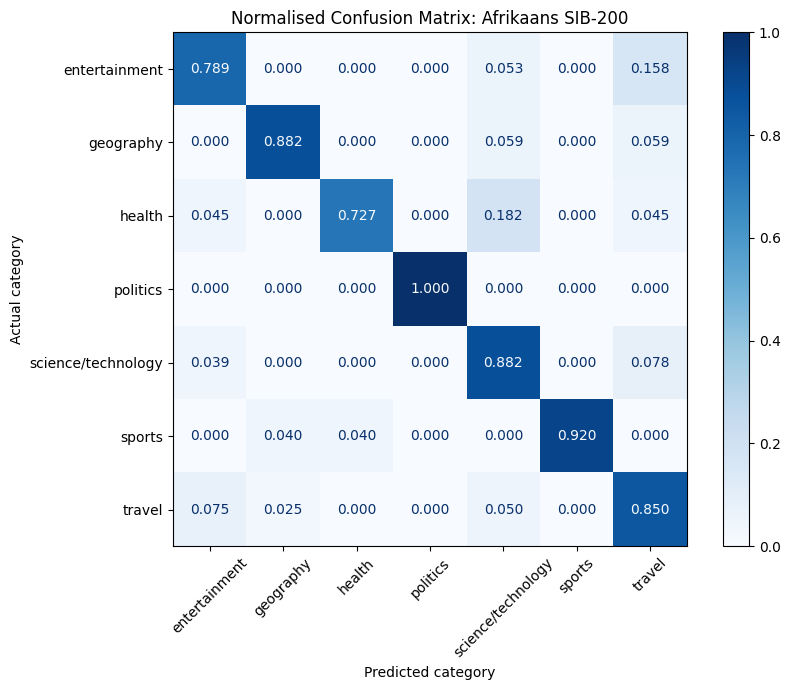

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    normalize="true",       # normalise each actual class
    values_format=".3f",
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

ax.set_title("Normalised Confusion Matrix: Afrikaans SIB-200")
ax.set_xlabel("Predicted category")
ax.set_ylabel("Actual category")

plt.tight_layout()
plt.show()

## Conclusion

`MzansiLM` achieved a macro-F1 of **0.871** on Afrikaans SIB-200 when topic classification was formulated as a `generative next-token prediction task`. Performance was strongest for **politics** (F1 = **1.000**) and **sports** (F1 = **0.958**), while **entertainment** was the most difficult category (F1 = **0.750**). This shows (suggests) that a small decoder-only language model can perform competitive topic classification by generating class labels rather than using a dedicated classification head.

## Next Steps

* Read the `MzansiLM` paper.
* Experiment with `xho_Latn`, `zul_Latn`, `sot_Latn`, `nso_Latn`, `tsn_Latn`, and `tso_Latn`.
* Compare this against a standard encoder classifier on the same Afrikaans SIB-200 split, for example `XLM-R` or `AfroXLM-R`.

### South African languages support

In [54]:
from datasets import get_dataset_config_names
import pandas as pd

all_configs = get_dataset_config_names("Davlan/sib200")

sa_languages = {
    "Afrikaans": "afr_Latn",
    "English": "eng_Latn",
    "Sepedi (Northern Sotho)": "nso_Latn",
    "Sesotho": "sot_Latn",
    "Setswana": "tsn_Latn",
    "siSwati": "ssw_Latn",
    "isiXhosa": "xho_Latn",
    "isiZulu": "zul_Latn",
    "Tsonga": "tso_Latn",
    "Tshivenda": "ven_Latn",
    "isiNdebele": "nbl_Latn"
}

sa_language_support = pd.DataFrame([
    {
        "language": language,
        "SIB-200 configuration": config,
        "available": config in all_configs
    }
    for language, config in sa_languages.items()
])

display(sa_language_support)

,language,SIB-200 configuration,available
0,Afrikaans,afr_Latn,True
1,English,eng_Latn,True
2,Sepedi (Northern Sotho),nso_Latn,True
3,Sesotho,sot_Latn,True
4,Setswana,tsn_Latn,True
5,siSwati,ssw_Latn,True
6,isiXhosa,xho_Latn,True
7,isiZulu,zul_Latn,True
8,Tsonga,tso_Latn,True
9,Tshivenda,ven_Latn,False


### Create a multilingual dataset

In [55]:
from datasets import load_dataset

xhosa = load_dataset("Davlan/sib200", "xho_Latn")
zulu = load_dataset("Davlan/sib200", "zul_Latn")
sesotho = load_dataset("Davlan/sib200", "sot_Latn")

xhosa = xhosa.map(lambda x: {"language": "isiXhosa"})
zulu = zulu.map(lambda x: {"language": "isiZulu"})
sesotho = sesotho.map(lambda x: {"language": "Sesotho"})

In [56]:
print(xhosa)
print(zulu)
print(sesotho)

DatasetDict({
    train: Dataset({
        features: ['index_id', 'category', 'text', 'language'],
        num_rows: 701
    })
    validation: Dataset({
        features: ['index_id', 'category', 'text', 'language'],
        num_rows: 99
    })
    test: Dataset({
        features: ['index_id', 'category', 'text', 'language'],
        num_rows: 204
    })
})
DatasetDict({
    train: Dataset({
        features: ['index_id', 'category', 'text', 'language'],
        num_rows: 701
    })
    validation: Dataset({
        features: ['index_id', 'category', 'text', 'language'],
        num_rows: 99
    })
    test: Dataset({
        features: ['index_id', 'category', 'text', 'language'],
        num_rows: 204
    })
})
DatasetDict({
    train: Dataset({
        features: ['index_id', 'category', 'text', 'language'],
        num_rows: 701
    })
    validation: Dataset({
        features: ['index_id', 'category', 'text', 'language'],
        num_rows: 99
    })
    test: Dataset({
        fe

In [57]:
from datasets import DatasetDict, concatenate_datasets

dataset = DatasetDict({
    "train": concatenate_datasets([
        xhosa["train"],
        zulu["train"],
        sesotho["train"]
    ]),

    "validation": concatenate_datasets([
        xhosa["validation"],
        zulu["validation"],
        sesotho["validation"]
    ]),

    "test": concatenate_datasets([
        xhosa["test"],
        zulu["test"],
        sesotho["test"]
    ])
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['index_id', 'category', 'text', 'language'],
        num_rows: 2103
    })
    validation: Dataset({
        features: ['index_id', 'category', 'text', 'language'],
        num_rows: 297
    })
    test: Dataset({
        features: ['index_id', 'category', 'text', 'language'],
        num_rows: 612
    })
})


Note they all have English labels...which means, it can learn the **same classification task across languages**.

In [58]:
print(set(dataset["train"]["category"]))

{'sports', 'health', 'politics', 'geography', 'entertainment', 'science/technology', 'travel'}


### Change the prompt

And this will become our new prompt in training and inference...

... then `fine-tune` and `inference` again ...